**Name : Darpan**

**CMS-ID** 023-24-0237

**Guthub:Repo** 

In [27]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

## Part 1 — Decision Tree Baseline Review 

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same
random_state).
2. Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and
F1-score on the test set. This is your benchmark for the rest of the lab.

In [28]:
## 1 
from sklearn.model_selection import train_test_split

## Reload cleaned dataset 

df = pd.read_csv("clean_churn.csv")

## recreate y 

y = df["Churn"].map({"No": 0, "Yes" : 1})

#  Recreate X (drop target + identifier)
X = df.drop(columns=["Churn","customerID"])

X["gender"] = X["gender"].map({"Male": 1, "Female": 0})

for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]:
    X[col] = X[col].map({"Yes": 1, "No": 0})


onehot_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
               "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
               "Contract", "PaymentMethod"]

X = pd.get_dummies(X,columns=onehot_cols,drop_first=True)

X[X.select_dtypes(include="bool").columns] = X.select_dtypes(include="bool").astype(int)

In [21]:
# Train Test Split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state = 42)

## task2 :
## Benchmark Model (Decision Tree, max_depth=5, gini)

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [35]:
## train the model 
bench_markmodel = DecisionTreeClassifier(max_depth=5,random_state = 42)
bench_markmodel.fit(X_train,y_train)
y_pred_dt = bench_markmodel.predict(X_test)

print("Accuracy_Score : ",accuracy_score(y_test,y_pred_dt))
print("Precision Score :",precision_score(y_test,y_pred_dt))
print("Recall Score :",recall_score(y_test,y_pred_dt))
print("F1 Score :",f1_score(y_test,y_pred_dt))

Accuracy_Score :  0.8062455642299503
Precision Score : 0.7049180327868853
Recall Score : 0.46112600536193027
F1 Score : 0.5575364667747164


##  Part 2 — Random Forest

**Tasks 3**
 Train a RandomForestClassifier on the same training data (reasonable default n_estimators, e.g. 100–300; fix
random_state). Generate predictions on the test set.


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf =  RandomForestClassifier(n_estimators=200,random_state = 42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("Precision Score : ",precision_score(y_test,y_pred))
print("Recall Score :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))

Accuracy Score :  0.7977288857345636
Precision Score :  0.662962962962963
Recall Score : 0.47989276139410186
F1 Score : 0.5567651632970451


**Task 4**
In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single 
unrestricted Decision Tree.

**Ans**
A Random Forest trains many trees on different random subsets of  data and features,

then averages their predictions so individual overfitting mistakes tend to cancel out.

A single unrestricted tree has no such averaging, so it just memorizes noise instead of
learning patterns that generalize

## Part 3 — Evaluation & Comparison

**Task 5**
Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion
matrix.

In [31]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

Accuracy:  0.7977288857345636
Precision: 0.662962962962963
Recall:    0.47989276139410186
F1-score:  0.5567651632970451


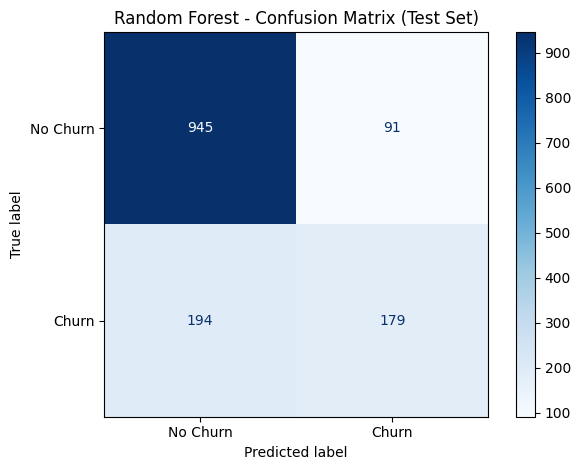

In [32]:
y_pred_rf = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf)
rec = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)

print("Accuracy: ", acc)
print("Precision:", prec)
print("Recall:   ", rec)
print("F1-score: ", f1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

**Task6**
Build a single comparison table: Decision Tree (Part 1)
vs. Random Forest (Part 2), across all four metrics. 


In [37]:
y_pred_rf = rf.predict(X_test)

comparison_df = pd.DataFrame({
    "Model": ["Decision Tree (max_depth=5)", "Random Forest (n_estimators=200)"],
    "Accuracy":  [accuracy_score(y_test, y_pred_dt),  accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    "Recall":    [recall_score(y_test, y_pred_dt),    recall_score(y_test, y_pred_rf)],
    "F1-score":  [f1_score(y_test, y_pred_dt),         f1_score(y_test, y_pred_rf)],
})
print(comparison_df.to_string(index=False))
comparison_df.to_csv("model_comparison.csv", index=False)

                           Model  Accuracy  Precision   Recall  F1-score
     Decision Tree (max_depth=5)  0.806246   0.704918 0.461126  0.557536
Random Forest (n_estimators=200)  0.797729   0.662963 0.479893  0.556765


**Task 7**
 Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 
2/3's finding about class imbalance, which metric matters most here?

**Ans**
The Decision Tree wins on accuracy, precision, and F1-score, 
while the Random Forest wins only on recall.

The differences are marginal across the board:

Accuracy gap: 0.0085 (less than 1 point)
Precision gap: 0.0419 (~4 points)
Recall gap: 0.0188 (~2 points)
F1-score gap: 0.0007 (essentially tied)

Recall matters most here. Since only ~27% of customers actually churn, the business risk is missing real churners (false negatives) — those are customers who leave without any retention intervention, since the model failed to flag them. Accuracy is misleading with imbalanced classes (a model could get ~73% accuracy just by always predicting "No Churn"), and while precision matters for not wasting retention budget on false alarms, the cost of missing an actual churner is usually higher than the cost of a wasted retention offer.

By that lens, the Random Forest is arguably the better practical choice here, since it has the higher recall (0.48 vs 0.46) — even though the Decision Tree wins on the other three metrics. This highlights why picking a "best" model isn't just about the highest overall number; it depends on which type of error matters more for the actual business problem

## Part 4 — Cross-Validation

**Task 8**
Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain 
accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores. 

In [39]:
from sklearn.model_selection import cross_val_score
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring="f1")
rf_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="f1")
print("Decision Tree fold F1 scores:", np.round(dt_scores, 4))
print("DT means : ",dt_scores.mean())
print("DT standard deviation ", dt_scores.std())

print("Random Forest fold F1 scores:", np.round(dt_scores, 4))
print("Random forest means : ",rf_scores.mean())
print("Random  standard deviation ", rf_scores.std())

Decision Tree fold F1 scores: [0.6055 0.5341 0.5933 0.5556 0.5405]
DT means :  0.5658082031743634
DT standard deviation  0.02855785765459559
Random Forest fold F1 scores: [0.6055 0.5341 0.5933 0.5556 0.5405]
Random forest means :  0.552674976414065
Random  standard deviation  0.032095611578003835


**Task 9**
How do the cross-validated results compare to your single train/test split results from Part 3? Do they change 
your view of which model is better, or how confident you are in that conclusion? 

**Ans**
The single train/test split showed both models were almost tied on F1-score, and cross-validation confirms the same thing — Decision Tree still slightly ahead (0.5658 vs 0.5527). But cross-validation also shows each model's score swings by about ±0.03 across folds, which is bigger than the gap between them. So the "Decision Tree is better" conclusion doesn't change, but I'm now less confident it's a real difference rather than just noise — the two models are basically tied in practice.

## Part 5 — Hyperparameter Tuning

**Task 10**
 Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and 
define a small grid for each. Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best 
combination. 

In [41]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",   # same metric used in cross-validation earlier
    n_jobs=-1       # use all CPU cores to speed up search
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score : ",grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1 score :  0.5762050491292776


In [ ]:
## This grid searched 3 × 4 × 3 = 36 combinations, each evaluated with 5-fold cross-validation
## (180 model fits total)

**Task 11**

Report the best hyperparameters found and the corresponding cross-validated score. 

**Ans:**
Hyperparameter	Best Value
n_estimators = 200
max_depth	=10
min_samples_split	=10

Best cross-validated F1 score: 0.5762


**Task 12**

 Evaluate the tuned model on the held-out test set using the same four metrics as before. 

In [45]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)


print("Accuracy: ", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:   ", recall_score(y_test, y_pred_tuned))
print("F1-score: ", f1_score(y_test, y_pred_tuned))
print("Confusion MATRIX ")
print(confusion_matrix(y_test, y_pred_tuned))

Accuracy:  0.8126330731014905
Precision: 0.6981818181818182
Recall:    0.514745308310992
F1-score:  0.5925925925925926
Confusion MATRIX 
[[953  83]
 [181 192]]


## Part 6 — Final Comparison & Feature Importance 

**Task 13**
 Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned 
Random Forest — accuracy, precision, recall, F1-score for each. 

In [46]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Model": ["Decision Tree (max_depth=5)", "Random Forest (default, n=200)", "Tuned Random Forest"],
    "Accuracy":  [accuracy_score(y_test, y_pred_dt),  accuracy_score(y_test, y_pred_rf),  accuracy_score(y_test, y_pred_tuned)],
    "Precision": [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_tuned)],
    "Recall":    [recall_score(y_test, y_pred_dt),    recall_score(y_test, y_pred_rf),    recall_score(y_test, y_pred_tuned)],
    "F1-score":  [f1_score(y_test, y_pred_dt),         f1_score(y_test, y_pred_rf),         f1_score(y_test, y_pred_tuned)],
})

print(final_comparison.to_string(index=False))
final_comparison.to_csv("final_model_comparison.csv", index=False)

                         Model  Accuracy  Precision   Recall  F1-score
   Decision Tree (max_depth=5)  0.806246   0.704918 0.461126  0.557536
Random Forest (default, n=200)  0.797729   0.662963 0.479893  0.556765
           Tuned Random Forest  0.812633   0.698182 0.514745  0.592593


**Task 14**
Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best 
training score alone is not sufficient justification. 

**Ans**

I select the Tuned Random Forest as my final model, since it achieves the highest accuracy (0.8126), recall (0.5147), and F1-score (0.5926) on the held-out test set, not just during cross-validation. Given the class imbalance from Lab 2/3, its higher recall (catching 192 actual churners) matters more than its slightly lower precision, since missing a real churner costs more than a false alarm.

**Task 15**
. Extract and visualize feature_importances_ for your final model
. Which 3–5 features matter most, and do they 
agree with what Lab 2's EDA and Lab 3's Decision Tree suggested? 

                       feature  importance
                        tenure    0.198052
                  TotalCharges    0.162647
                MonthlyCharges    0.114632
   InternetService_Fiber optic    0.066988
             Contract_Two year    0.062207
PaymentMethod_Electronic check    0.060871
            OnlineSecurity_Yes    0.034394
             Contract_One year    0.031990
               TechSupport_Yes    0.025673
              PaperlessBilling    0.022209


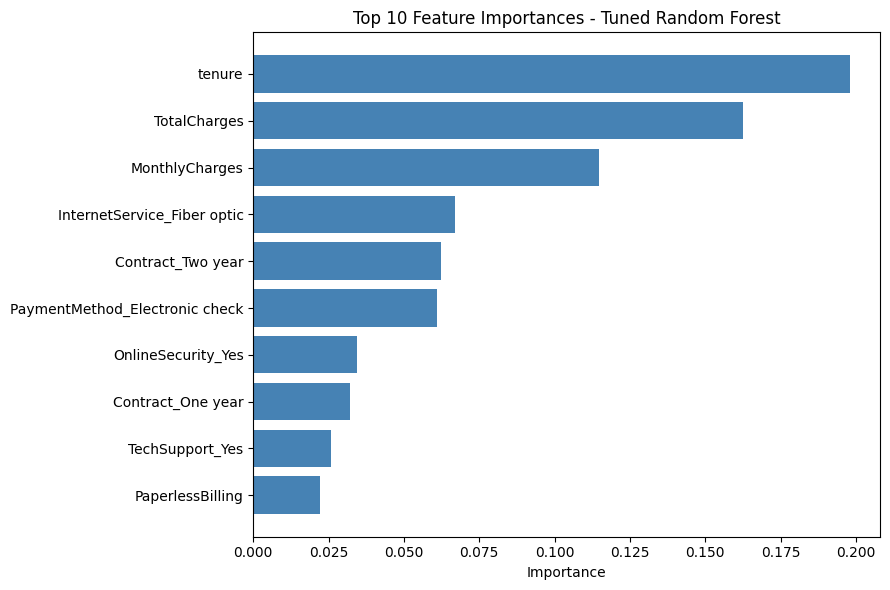

In [47]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.head(10).to_string(index=False))

import matplotlib.pyplot as plt
top10 = importances.head(10)
plt.figure(figsize=(9,6))
plt.barh(top10["feature"][::-1], top10["importance"][::-1], color="steelblue")
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Tuned Random Forest")
plt.tight_layout()
plt.show()

# Top 3–5 most important features in the tuned Random Forest:

## tenure (0.198)
## TotalCharges (0.163)
## MonthlyCharges (0.115)
## InternetService_Fiber optic (0.067)
## Contract_Two year (0.062)


# do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

## Partially yes, but with an interesting shift in emphasis. tenure remains the top feature in both models,
## consistent with Lab 2's EDA, which likely showed newer customers churning more often. InternetService_Fiber optic also shows up promine



## tenure remains the top feature in both models, matching Lab 2's EDA finding that newer customers churn more
## . InternetService_Fiber optic also shows up prominently in both, consistent with fiber customers having higher churn rates.
##     However, the Random Forest spreads importance more evenly across TotalCharges, MonthlyCharges, 
## and Contract type, while the single Decision Tree relied almost entirely (~80%) on just tenure and fiber optic.
##     This happens because a single tree locks onto the strongest splits early and ignores correlated variables,
##     whereas the Random Forest's random feature selection at each split forces it to also use billing and contract features.
##     So overall, both models agree on the top drivers, but the Random Forest reveals additional useful signal that the single tree missed.

# Part 7 — Kaggle Submission & Conclusion

**Task 16**
6. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and 
assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save 
it as submission.csv

In [48]:
# Keep customerID aligned with X/y via matching split
customer_ids = df["customerID"]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids, test_size=0.2, random_state=42
)

# (Re-fit best_rf on this split if not already fitted)
y_pred = best_rf.predict(X_test)

# Map 0/1 predictions back to readable Yes/No labels
pred_labels = pd.Series(y_pred).map({0: "No", 1: "Yes"})

submission = pd.DataFrame({
    "customerID": id_test.values,
    "Churn": pred_labels.values
})

submission.to_csv("submission.csv", index=False)

**Task 17**

I ultimately chose the Tuned Random Forest as my final model, since it improved accuracy (0.8126), recall (0.5147), and F1-score (0.5926) over the Lab 3 Decision Tree, though precision was slightly lower.
Feature importance confirmed tenure, billing,
and contract/internet type as the key churn drivers,
matching Lab 2's EDA and Lab 3's findings, but spread more evenly across features. Its main limitation is still recall — it misses about half of actual churners, so many at-risk customers go undetected. It's also less interpretable 
than a single Decision Tree since it combines 200 trees into a black-box ensemble.    
Future improvements could come from handling class imbalance directly (e.g., SMOTE, class weighting) or trying gradient boosting methods like XGBoost.

**Task 18**
 What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class 
imbalance directly)? Describe it — do not implement it here. 

**Ans**
Handle class imbalance directly (SMOTE or class weighting) to improve recall
Test gradient boosting models like XGBoost, which often outperform Random Forests on tabular data
Do deeper hyperparameter tuning (RandomizedSearchCV with more parameters)
Adjust the classification threshold to catch more true churners